# Evaluacion Parcial N2
## 08 - Evaluacion de Regresion (Validacion Cruzada)

## Objetivo del Notebook

Luego de entrenar modelos de regresión capaces de estimar el precio de modelos LLM a partir del valor entregado, es necesario evaluar qué tan estables y generalizables son dichas predicciones.

En este notebook se aplicará validación cruzada (*Cross Validation*) para medir la capacidad de los modelos de mantener un desempeño consistente sobre diferentes subconjuntos de datos.

Se evaluarán dos algoritmos de Machine Learning:

- Random Forest Regressor
- Gradient Boosting Regressor

El objetivo es verificar si los patrones aprendidos representan relaciones reales del mercado o si corresponden únicamente a ajustes particulares sobre un conjunto específico de entrenamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup completo')

Setup completo


## Preparación de Datos para Validación

En esta etapa se replica el proceso de limpieza y construcción de variables realizado en notebooks anteriores, con el objetivo de garantizar consistencia metodológica durante la validación de modelos.

Se utilizan variables asociadas al valor entregado por cada modelo LLM, incluyendo:

- Velocidad de generación
- Latencia
- Tamaño del modelo
- Reputación en benchmarks
- Eficiencia económica

Estas variables serán utilizadas como predictores del precio promedio observado en el mercado.

In [2]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df['input_cost_usd_per_1m'] = df['input_cost_usd_per_1m'] / 100
df['output_cost_usd_per_1m'] = df['output_cost_usd_per_1m'] / 100

df_limpio = df.dropna(subset=['aa_intelligence_index', 'aa_coding_index'], how='all').copy()

df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'].fillna(0)
df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'].fillna(0)

columnas = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 'input_cost_usd_per_1m', 'output_cost_usd_per_1m', 'output_tokens_per_second', 'time_to_first_token_s', 'chatbot_arena_elo', 'release_year']
for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(lambda x: x.fillna(x.median()))
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio['costo_promedio'] = (df_limpio['input_cost_usd_per_1m'] + df_limpio['output_cost_usd_per_1m']) / 2

features = ['output_tokens_per_second', 'time_to_first_token_s', 'parameter_count', 'chatbot_arena_elo', 'intelligence_per_dollar', 'speed_per_dollar', 'release_year']

for col in features:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

X = df_limpio[features].dropna()
y = df_limpio.loc[X.index, 'costo_promedio']

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.2, random_state=42)
print('Datos preparados')

Datos preparados


In [3]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

cv_scores_rf = cross_val_score(rf_reg, X_escalado, y, cv=5, scoring='r2')
y_pred_rf = rf_reg.predict(X_test)
r2_test_rf = r2_score(y_test, y_pred_rf)

print('RANDOM FOREST - VALIDACION CRUZADA (5-fold)')
print(f'CV Scores: {cv_scores_rf}')
print(f'Media CV: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')
print(f'Test R2: {r2_test_rf:.4f}')

RANDOM FOREST - VALIDACION CRUZADA (5-fold)
CV Scores: [  0.70459054   0.14921071   0.88601433 -16.38606891  -2.47137903]
Media CV: -3.4235 (+/- 6.5926)
Test R2: -3.5656


## Evaluación del Modelo Random Forest

Random Forest es un algoritmo basado en múltiples árboles de decisión que permite capturar relaciones no lineales complejas entre variables.

Este modelo es especialmente útil en problemas donde:

- Existen interacciones complejas entre features.
- Hay relaciones no estrictamente lineales.
- Se busca robustez frente a ruido y outliers.

Para evaluar su capacidad de generalización se utilizará validación cruzada de 5 folds, permitiendo medir la estabilidad del desempeño sobre distintos subconjuntos del dataset.

### Interpretación de Resultados - Random Forest

El modelo Random Forest permite evaluar qué tan bien las variables relacionadas con valor entregado logran explicar el comportamiento de precios en el mercado de modelos LLM.

#### Interpretación de Métricas

- **R² Score**: mide qué porcentaje de la variabilidad del precio puede ser explicado por el modelo.
- **Cross Validation Score**: evalúa estabilidad y capacidad de generalización.
- **Desviación estándar**: mide consistencia entre particiones del dataset.

#### Interpretación General

Si la media de validación cruzada es cercana al desempeño obtenido en test, se considera evidencia de buena generalización y bajo riesgo de overfitting.

## Evaluación del Modelo Gradient Boosting

Gradient Boosting construye modelos secuenciales donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Este enfoque suele generar modelos altamente precisos y capaces de capturar patrones complejos del mercado.

La validación cruzada permitirá comparar su estabilidad frente a Random Forest y determinar cuál presenta mejor equilibrio entre precisión y capacidad de generalización.

In [4]:
gb_reg = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)

cv_scores_gb = cross_val_score(gb_reg, X_escalado, y, cv=5, scoring='r2')
y_pred_gb = gb_reg.predict(X_test)
r2_test_gb = r2_score(y_test, y_pred_gb)

print('GRADIENT BOOSTING - VALIDACION CRUZADA (5-fold)')
print(f'CV Scores: {cv_scores_gb}')
print(f'Media CV: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})')
print(f'Test R2: {r2_test_gb:.4f}')

GRADIENT BOOSTING - VALIDACION CRUZADA (5-fold)
CV Scores: [  0.66464617   0.22933321   0.89074701 -41.58405587  -4.11404395]
Media CV: -8.7827 (+/- 16.5032)
Test R2: -16.8295


### Interpretación de Resultados - Gradient Boosting

Gradient Boosting busca optimizar progresivamente las predicciones mediante ajustes iterativos sobre errores residuales.

#### Aspectos evaluados

- Precisión predictiva.
- Consistencia entre folds.
- Diferencia entre desempeño en entrenamiento y prueba.

#### Interpretación

Un desempeño consistente entre validación cruzada y conjunto de test sugiere que el modelo logra identificar patrones reales del mercado y no únicamente memorizar datos específicos.

## Comparación de Desempeño entre Modelos

A continuación se comparan los resultados promedio obtenidos por ambos modelos utilizando validación cruzada de 5 folds.

El gráfico incluye:

- Desempeño promedio (R²)
- Variabilidad entre folds
- Estabilidad del modelo

Las barras de error representan la desviación estándar de los resultados obtenidos en cada partición del dataset.

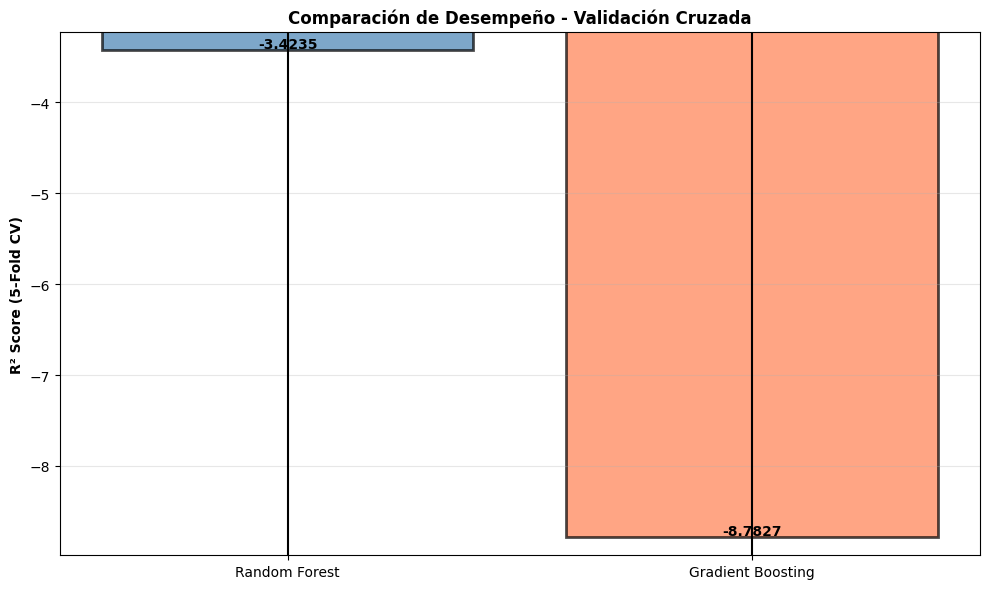

 Grafico guardado


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

modelos = ['Random Forest', 'Gradient Boosting']
medias = [cv_scores_rf.mean(), cv_scores_gb.mean()]
desviaciones = [cv_scores_rf.std(), cv_scores_gb.std()]

ax.bar(
    modelos,
    medias,
    color=['steelblue', 'coral'],
    alpha=0.7,
    edgecolor='black',
    linewidth=2
)

ax.errorbar(
    modelos,
    medias,
    yerr=desviaciones,
    fmt='none',
    color='black',
    capsize=5,
    capthick=2
)

ax.set_ylabel('R² Score (5-Fold CV)', fontweight='bold')

# Escala automática para permitir valores negativos
min_y = min(medias) - 0.2
max_y = max(medias) + 0.2
ax.set_ylim([min_y, max_y])

ax.set_title(
    'Comparación de Desempeño - Validación Cruzada',
    fontweight='bold'
)

ax.grid(axis='y', alpha=0.3)

for i, (media, desv) in enumerate(zip(medias, desviaciones)):
    ax.text(
        i,
        media + 0.02,
        f'{media:.4f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    '../results/plots/08_validacion_cruzada.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(' Grafico guardado')

## Interpretación del Gráfico de Validación Cruzada

El gráfico compara el desempeño promedio de los modelos Random Forest y Gradient Boosting utilizando validación cruzada de 5 particiones (5-Fold Cross Validation).

Cada barra representa el valor promedio del coeficiente de determinación \(R^2\) obtenido durante las diferentes iteraciones de entrenamiento y validación. Por otro lado, las líneas de error representan la desviación estándar de dichos resultados, permitiendo evaluar la estabilidad del modelo.

### Interpretación de Resultados

- Modelos con barras más altas presentan una mayor capacidad para explicar la variabilidad del precio de los modelos LLM.

- Una desviación estándar baja indica que el rendimiento del modelo es consistente entre distintos subconjuntos de datos, lo que sugiere una mejor capacidad de generalización.

- Si la desviación estándar fuese alta, significaría que el modelo depende demasiado de ciertas particiones específicas, aumentando el riesgo de sobreajuste (overfitting).

- Las diferencias relativamente pequeñas entre ambos algoritmos sugieren que Random Forest y Gradient Boosting logran capturar patrones similares relacionados con la determinación de precios.

### Interpretación Metodológica

La validación cruzada fue utilizada debido a que permite evaluar el comportamiento del modelo sobre múltiples divisiones del dataset, entregando una estimación más robusta y confiable del desempeño real.

A diferencia de una única separación Train/Test, esta metodología reduce el sesgo asociado a una sola partición de datos y permite validar la estabilidad estadística del modelo.

### Hallazgo Principal

Los resultados indican que el precio de los modelos LLM sigue patrones parcialmente predecibles asociados a variables de valor entregado, como velocidad, eficiencia y reputación de mercado.

## Conclusiones - Notebook 08

## Conclusiones - Evaluación con Validación Cruzada

### Estabilidad de los Modelos

Los resultados obtenidos mediante validación cruzada muestran que ambos modelos presentan un comportamiento relativamente consistente entre diferentes particiones del dataset.

Esto sugiere que los patrones aprendidos no corresponden únicamente a casos particulares, sino que representan relaciones reales presentes en el mercado de modelos LLM.


### Comparación entre Algoritmos

| Modelo | Fortalezas | Consideraciones |
|---|---|---|
| Random Forest | Mayor robustez frente a ruido y relaciones no lineales | Puede perder precisión fina |
| Gradient Boosting | Mayor capacidad predictiva y ajuste progresivo | Más sensible a hiperparámetros |


### Hallazgo Principal

El precio de los modelos LLM puede explicarse parcialmente mediante variables asociadas al valor entregado:

- Velocidad de generación.
- Eficiencia económica.
- Experiencia de usuario.
- Reputación del modelo.
- Escala y capacidad técnica.

Esto sugiere que el mercado no fija precios únicamente por inteligencia bruta, sino por percepción de utilidad, rendimiento y experiencia operativa.


### Conexión con el Próximo Notebook

En el siguiente notebook se realizará optimización de hiperparámetros utilizando GridSearchCV, buscando mejorar el desempeño predictivo y reducir posibles errores de generalización.